# Grid Search v2: Focused Parameter Comparison

Based on findings from `debug_lsp_pipeline.ipynb`:
- Fixed: `diameter=2`, `anatomical_only=4` (max_proj)
- Search: `high_pass` (0, 100) and `spatial_hp_cp` (0, 0.5)

This gives us 4 combinations to compare mask outputs visually.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time
import shutil

import lbm_suite2p_python as lsp

print(f"lbm_suite2p_python version: {lsp.__version__}")

lbm_suite2p_python version: 2.3.0


## Configuration

In [2]:
# Path to registered binary (from previous processing)
S2P_DIR = Path(r"D:\cj\2025-11-21\results\plane01_stitched")
OUTPUT_DIR = S2P_DIR.parent / "grid_search_v2"
OUTPUT_DIR.mkdir(exist_ok=True)

# Get the registered binary
reg_bin = S2P_DIR / "data.bin"
if not reg_bin.exists():
    reg_bin = S2P_DIR / "data_raw.bin"

print(f"Input binary: {reg_bin}")
print(f"Output directory: {OUTPUT_DIR}")

# Load ops to get image dimensions
ops = np.load(S2P_DIR / "ops.npy", allow_pickle=True).item()
Ly, Lx = ops['Ly'], ops['Lx']
max_proj = ops['max_proj'].astype(np.float32)
print(f"Image dimensions: {Ly} x {Lx}")

Input binary: D:\cj\2025-11-21\results\plane01_stitched\data.bin
Output directory: D:\cj\2025-11-21\results\grid_search_v2
Image dimensions: 772 x 735


## Define Grid Search Parameters

Fixed parameters:
- `diameter=2` (small cells)
- `anatomical_only=4` (max projection)
- `cellprob_threshold=-6` (permissive)
- `flow_threshold=0` (permissive)

Search parameters:
- `high_pass`: 0 (off), 100 (default)
- `spatial_hp_cp`: 0 (off), 0.5 (default)

In [3]:
# Fixed parameters
FIXED_OPS = {
    'do_registration': 0,
    'roidetect': 1,
    'anatomical_only': 4,
    'diameter': 2,
    'cellprob_threshold': -6.0,
    'flow_threshold': 0.0,
}

# Grid search parameters
GRID_PARAMS = {
    'high_pass': [0, 100],
    'spatial_hp_cp': [0, 0.5],
}

# Generate all combinations
from itertools import product

param_names = list(GRID_PARAMS.keys())
param_values = list(GRID_PARAMS.values())
combinations = list(product(*param_values))

print(f"Fixed parameters: {FIXED_OPS}")
print(f"\nGrid search over: {GRID_PARAMS}")
print(f"Total combinations: {len(combinations)}")
for combo in combinations:
    combo_dict = dict(zip(param_names, combo))
    print(f"  {combo_dict}")

Fixed parameters: {'do_registration': 0, 'roidetect': 1, 'anatomical_only': 4, 'diameter': 2, 'cellprob_threshold': -6.0, 'flow_threshold': 0.0}

Grid search over: {'high_pass': [0, 100], 'spatial_hp_cp': [0, 0.5]}
Total combinations: 4
  {'high_pass': 0, 'spatial_hp_cp': 0}
  {'high_pass': 0, 'spatial_hp_cp': 0.5}
  {'high_pass': 100, 'spatial_hp_cp': 0}
  {'high_pass': 100, 'spatial_hp_cp': 0.5}


## Run Grid Search

In [4]:
results = {}

for combo in combinations:
    combo_dict = dict(zip(param_names, combo))

    # Create readable name
    name = f"hp{combo_dict['high_pass']}_spa{combo_dict['spatial_hp_cp']}"
    test_dir = OUTPUT_DIR / name

    # Clean previous run
    if test_dir.exists():
        shutil.rmtree(test_dir)

    # Merge fixed and grid params
    test_ops = {**FIXED_OPS, **combo_dict}

    print(f"\n{'='*60}")
    print(f"Running: {name}")
    print(f"  high_pass: {test_ops['high_pass']}")
    print(f"  spatial_hp_cp: {test_ops['spatial_hp_cp']}")
    print(f"{'='*60}")

    t0 = time.perf_counter()
    try:
        ops_files = lsp.pipeline(
            reg_bin,
            save_path=test_dir,
            ops=test_ops,
            keep_reg=True,
            keep_raw=False,
        )
        elapsed = time.perf_counter() - t0

        if ops_files:
            result_dir = Path(ops_files[0]).parent
            result_ops = np.load(result_dir / "ops.npy", allow_pickle=True).item()
            result_stat = np.load(result_dir / "stat.npy", allow_pickle=True)

            results[name] = {
                'n_cells': len(result_stat),
                'time': elapsed,
                'ops': result_ops,
                'stat': result_stat,
                'dir': result_dir,
                'params': combo_dict,
            }
            print(f"  Detected: {len(result_stat)} cells in {elapsed:.1f}s")
        else:
            print(f"  No ops files returned")
            results[name] = {'n_cells': 0, 'time': elapsed, 'error': 'No ops files', 'params': combo_dict}
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback
        traceback.print_exc()
        results[name] = {'n_cells': 0, 'time': 0, 'error': str(e), 'params': combo_dict}


Running: hp0_spa0
  high_pass: 0
  spatial_hp_cp: 0
Loading input data...
  Input: D:\cj\2025-11-21\results\plane01_stitched\data.bin
  Loaded as: Suite2pArray

Dataset info:
  Shape: (300, 772, 735)
  Frames: 300
  Planes: 1
  Dimensions: 772 x 735
  Frame rate: 5.40 Hz
Importing suite2p packages...

Processing plan:
  Planes: [1]
  Output: D:\cj\2025-11-21\results\grid_search_v2\hp0_spa0

Processing plane 1/1
  Writing binary (300 frames, 772x735)...


Saving data_raw.bin:   0%|          | 0/17 [00:00<?, ?it/s]

No pixel resolution found in metadata, using default [2, 2].


  Running Suite2p pipeline...
Registration skipped - copying data_raw.bin to data.bin...
  Copying data_raw.bin -> data.bin
  Using full image dimensions for anatomical detection (avoids cropping issues)
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- ROI DETECTION
Binning movie in chunks of length 07
Binned movie of size [42,772,735] created in 0.38 sec.


model_type argument is not used in v4.0.1+. Ignoring this argument...


...

  Running Suite2p pipeline...
Registration skipped - copying data_raw.bin to data.bin...
  Copying data_raw.bin -> data.bin
  Using full image dimensions for anatomical detection (avoids cropping issues)
NOTE: applying default C:\Users\RBO\.suite2p\classifiers\classifier_user.npy
----------- ROI DETECTION
Binning movie in chunks of length 07


model_type argument is not used in v4.0.1+. Ignoring this argument...


Binned movie of size [42,772,735] created in 0.38 sec.
>>>> CELLPOSE finding masks in max_proj
!NOTE! diameter set to 2.00 for cell detection with cellpose


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
Resizing is deprecated in v4.0.1+


>>>> 153 masks detected, median diameter = 6.28 
Detected 153 ROIs, 119.62 sec
After removing overlaps, 153 ROIs remain
----------- Total 120.25 sec.
----------- EXTRACTION
Masks created, 0.24 sec.
Extracted fluorescence from 153 ROIs in 300 frames, 0.26 sec.
----------- Total 0.54 sec.
----------- CLASSIFICATION
['npix_norm', 'compact', 'skew']
----------- SPIKE DECONVOLUTION
----------- Total 0.00 sec.
  Computing dF/F...
  Generating plots...
Plotting results for 118 accepted / 35 rejected ROIs
  Completed plane01 in 126.6s

Pipeline complete!
  Processed: 1 planes
  Time: 126.6s
  Output: D:\cj\2025-11-21\results\grid_search_v2\hp100_spa0.5
  Detected: 153 cells in 126.6s


## Results Summary

In [5]:
print("\n" + "="*70)
print("GRID SEARCH RESULTS")
print("="*70)
print(f"{'Name':<20} {'high_pass':>10} {'spatial_hp_cp':>15} {'Cells':>10} {'Time':>10}")
print("-"*70)

for name, r in results.items():
    hp = r['params']['high_pass']
    spa = r['params']['spatial_hp_cp']
    t = f"{r['time']:.1f}s" if 'time' in r else 'N/A'
    print(f"{name:<20} {hp:>10} {spa:>15} {r['n_cells']:>10} {t:>10}")


GRID SEARCH RESULTS
Name                  high_pass   spatial_hp_cp      Cells       Time
----------------------------------------------------------------------
hp0_spa0                      0               0          0       0.0s
hp0_spa0.5                    0             0.5          0       0.0s
hp100_spa0                  100               0        482     133.9s
hp100_spa0.5                100             0.5        153     126.6s


## Visualization Helpers

In [6]:
def normalize99(img):
    """Normalize image to 0-1 using 1st and 99th percentiles."""
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1 + 1e-8), 0, 1)

def stat_to_mask(stat, Ly, Lx):
    """Convert stat array to labeled mask."""
    mask = np.zeros((Ly, Lx), dtype=np.uint16)
    for i, s in enumerate(stat):
        ypix, xpix = s['ypix'], s['xpix']
        valid = (ypix >= 0) & (ypix < Ly) & (xpix >= 0) & (xpix < Lx)
        mask[ypix[valid], xpix[valid]] = i + 1
    return mask

def random_colors_for_mask(mask):
    """Generate random distinct colors for each cell ID in mask."""
    from matplotlib.colors import hsv_to_rgb
    n_cells = mask.max()
    if n_cells == 0:
        return np.zeros((*mask.shape, 3), dtype=np.float32)

    np.random.seed(42)  # For reproducibility
    hues = np.random.rand(n_cells + 1)
    saturations = 0.7 + 0.3 * np.random.rand(n_cells + 1)
    values = 0.8 + 0.2 * np.random.rand(n_cells + 1)

    colors = np.zeros((n_cells + 1, 3))
    for i in range(1, n_cells + 1):
        colors[i] = hsv_to_rgb([hues[i], saturations[i], values[i]])

    return colors[mask].astype(np.float32)

def mask_overlay(img, mask, alpha=0.5):
    """Overlay colored masks on grayscale image."""
    img_norm = normalize99(img)
    rgb = np.stack([img_norm] * 3, axis=-1).astype(np.float32)

    if mask.max() > 0:
        colors = random_colors_for_mask(mask)
        mask_px = mask > 0
        rgb[mask_px] = (1 - alpha) * rgb[mask_px] + alpha * colors[mask_px]

    return np.clip(rgb, 0, 1)

## Visual Comparison: Full Images

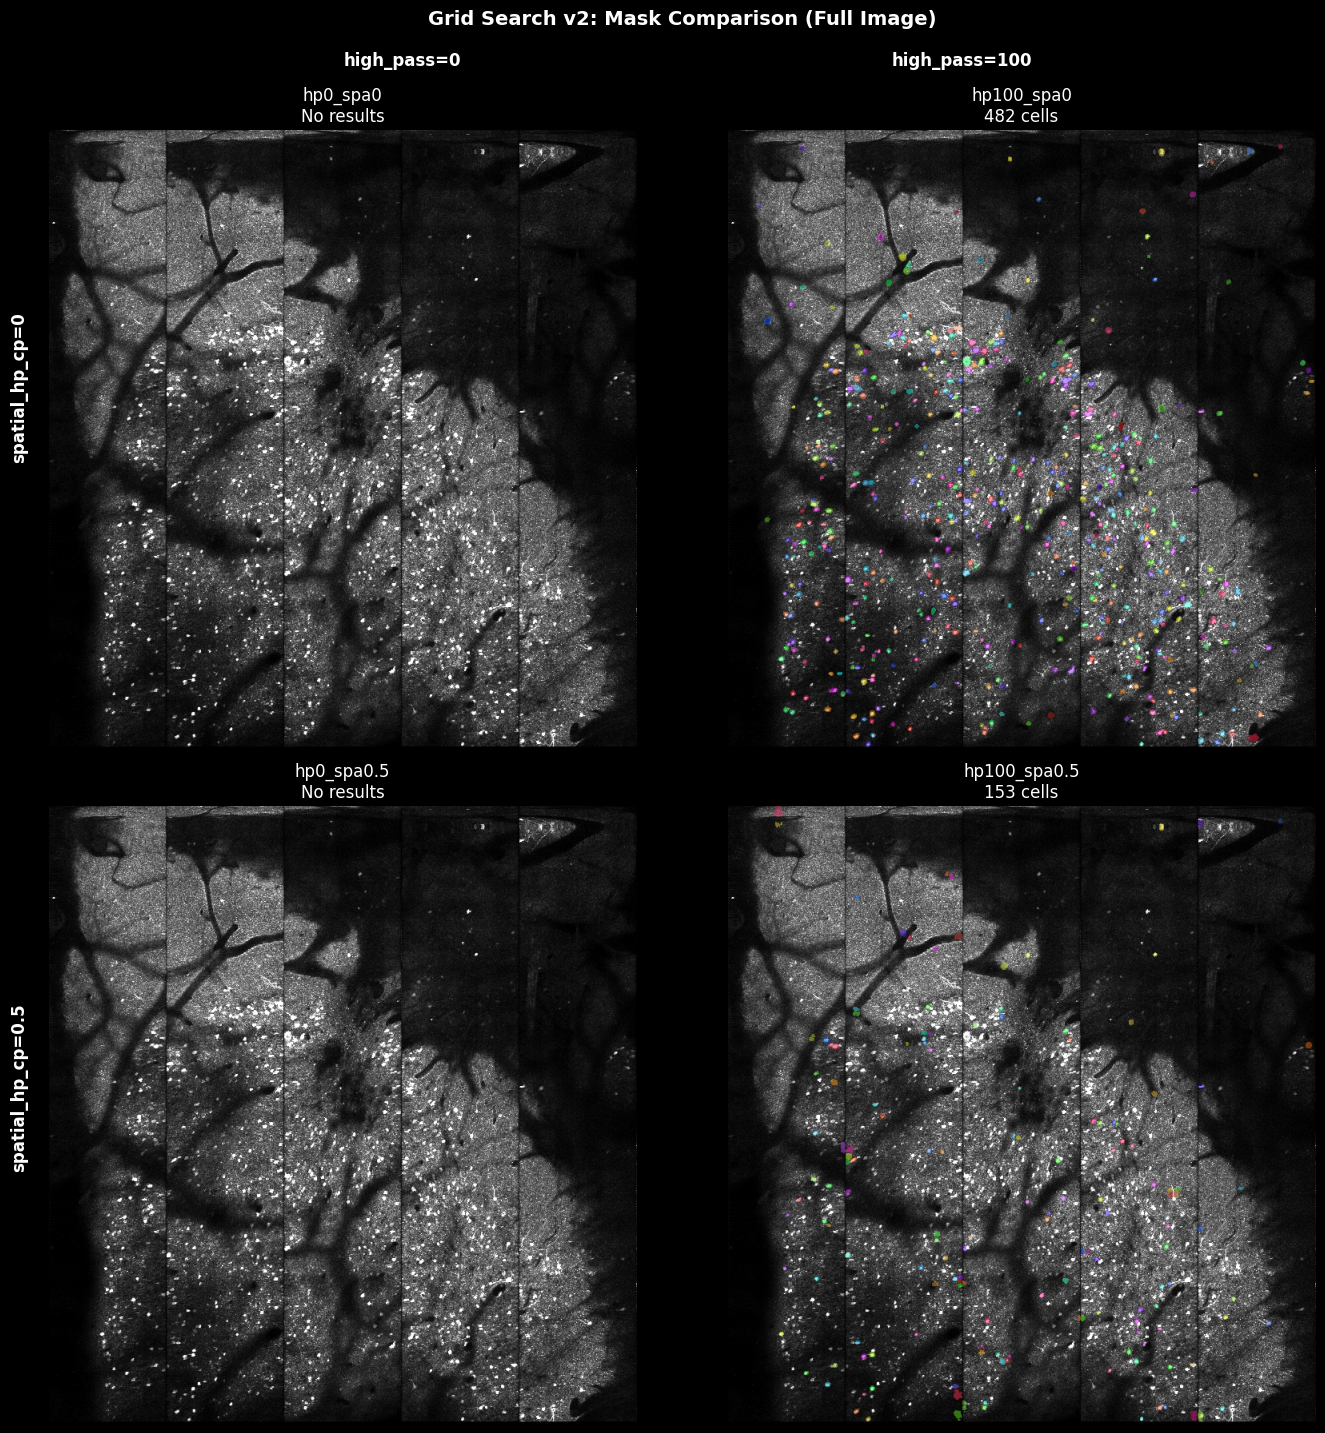

In [7]:
# Create 2x2 grid comparing all 4 combinations
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# Order: rows = spatial_hp_cp (0, 0.5), cols = high_pass (0, 100)
layout = [
    [('hp0_spa0', 0, 0), ('hp100_spa0', 0, 1)],
    [('hp0_spa0.5', 1, 0), ('hp100_spa0.5', 1, 1)],
]

for row_idx, row in enumerate(layout):
    for name, r_idx, c_idx in row:
        ax = axes[r_idx, c_idx]

        if name in results and 'stat' in results[name]:
            r = results[name]
            mask = stat_to_mask(r['stat'], Ly, Lx)
            overlay = mask_overlay(max_proj, mask)
            ax.imshow(overlay)
            ax.set_title(f"{name}\n{r['n_cells']} cells", fontsize=12)
        else:
            ax.imshow(normalize99(max_proj), cmap='gray')
            ax.set_title(f"{name}\nNo results", fontsize=12)
        ax.axis('off')

# Add row/column labels
fig.text(0.02, 0.75, 'spatial_hp_cp=0', va='center', rotation=90, fontsize=12, fontweight='bold')
fig.text(0.02, 0.25, 'spatial_hp_cp=0.5', va='center', rotation=90, fontsize=12, fontweight='bold')
fig.text(0.3, 0.98, 'high_pass=0', ha='center', fontsize=12, fontweight='bold')
fig.text(0.7, 0.98, 'high_pass=100', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Grid Search v2: Mask Comparison (Full Image)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparison_full.png', dpi=150, bbox_inches='tight')
plt.show()

## Visual Comparison: Zoomed Region

In [8]:
# Define zoom region (center of image)
zoom_size = 150
cy, cx = Ly // 2, Lx // 2
y1, y2 = max(0, cy - zoom_size), min(Ly, cy + zoom_size)
x1, x2 = max(0, cx - zoom_size), min(Lx, cx + zoom_size)

print(f"Zoom region: y=[{y1}:{y2}], x=[{x1}:{x2}]")

Zoom region: y=[236:536], x=[217:517]


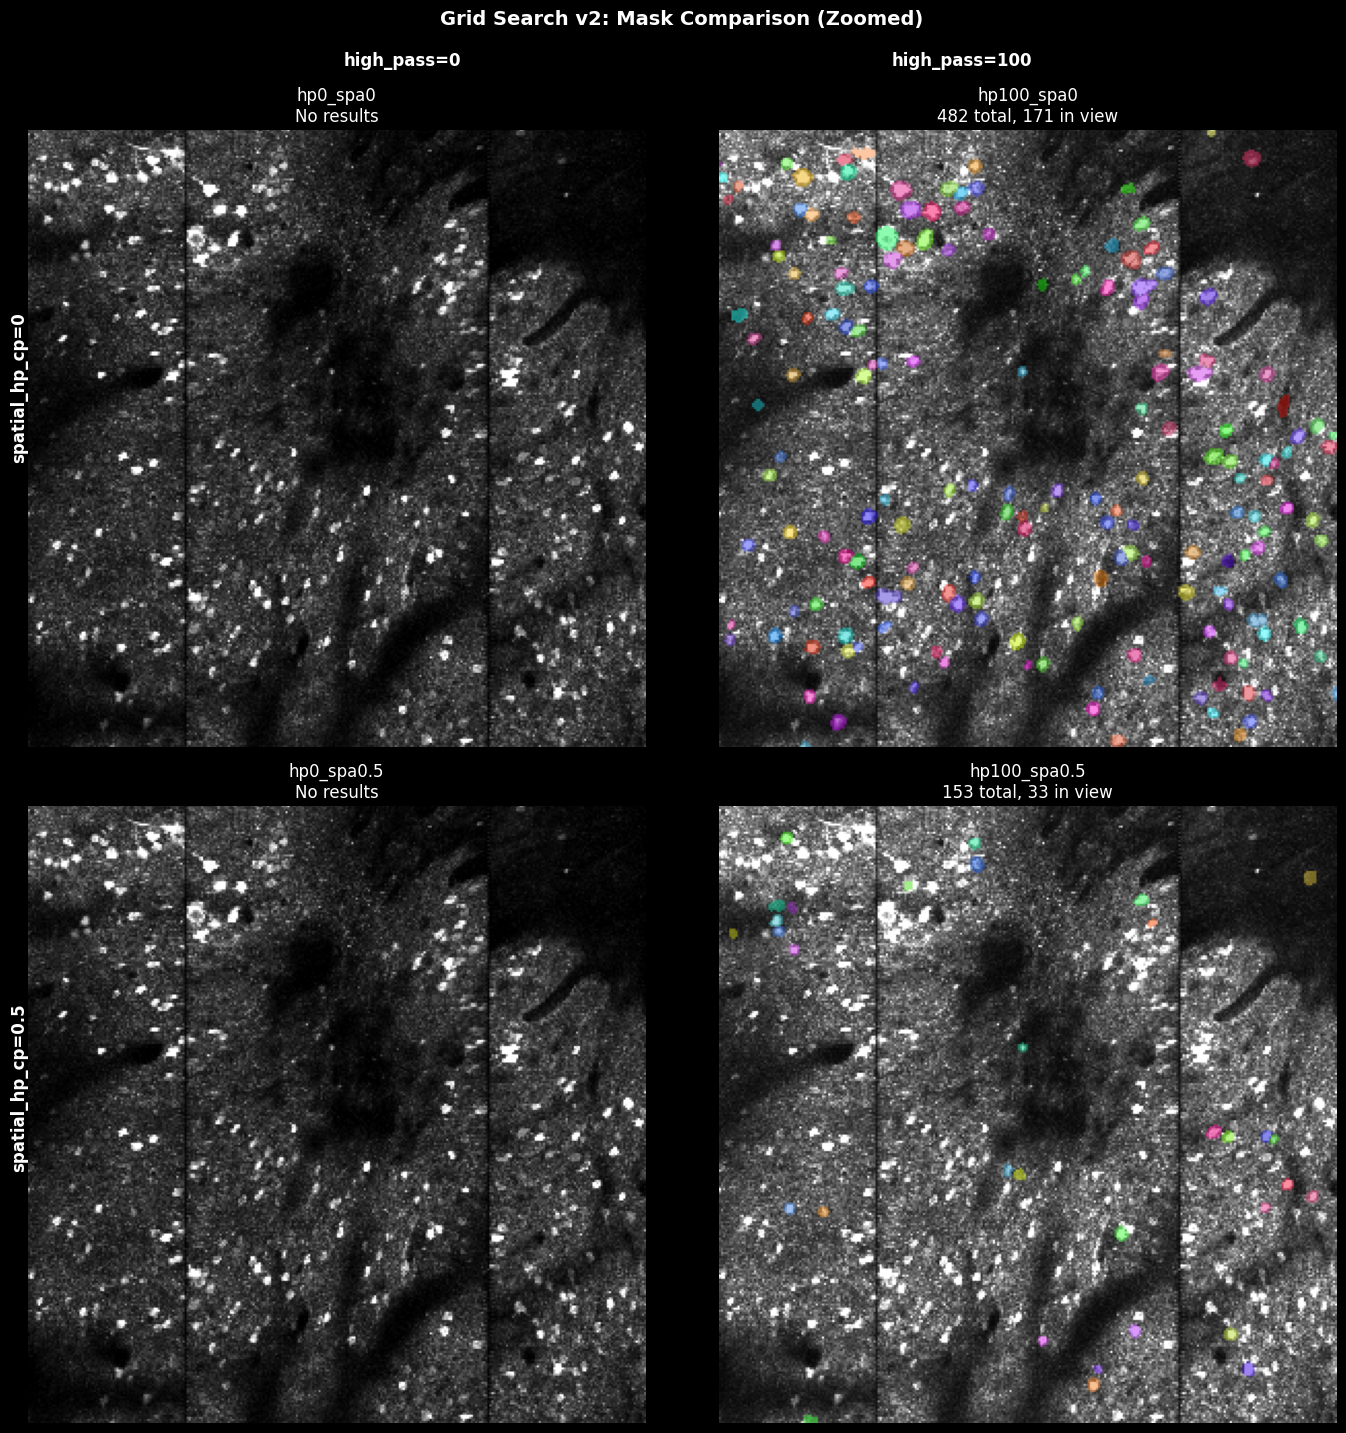

In [9]:
# Create 2x2 grid with zoomed views
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for row_idx, row in enumerate(layout):
    for name, r_idx, c_idx in row:
        ax = axes[r_idx, c_idx]

        if name in results and 'stat' in results[name]:
            r = results[name]
            mask = stat_to_mask(r['stat'], Ly, Lx)
            overlay = mask_overlay(max_proj, mask)
            ax.imshow(overlay[y1:y2, x1:x2])

            # Count cells in zoom region
            zoom_mask = mask[y1:y2, x1:x2]
            n_in_zoom = len(np.unique(zoom_mask)) - 1  # subtract background
            ax.set_title(f"{name}\n{r['n_cells']} total, {n_in_zoom} in view", fontsize=12)
        else:
            ax.imshow(normalize99(max_proj[y1:y2, x1:x2]), cmap='gray')
            ax.set_title(f"{name}\nNo results", fontsize=12)
        ax.axis('off')

# Add row/column labels
fig.text(0.02, 0.75, 'spatial_hp_cp=0', va='center', rotation=90, fontsize=12, fontweight='bold')
fig.text(0.02, 0.25, 'spatial_hp_cp=0.5', va='center', rotation=90, fontsize=12, fontweight='bold')
fig.text(0.3, 0.98, 'high_pass=0', ha='center', fontsize=12, fontweight='bold')
fig.text(0.7, 0.98, 'high_pass=100', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Grid Search v2: Mask Comparison (Zoomed)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparison_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

## Side-by-Side Pair Comparisons

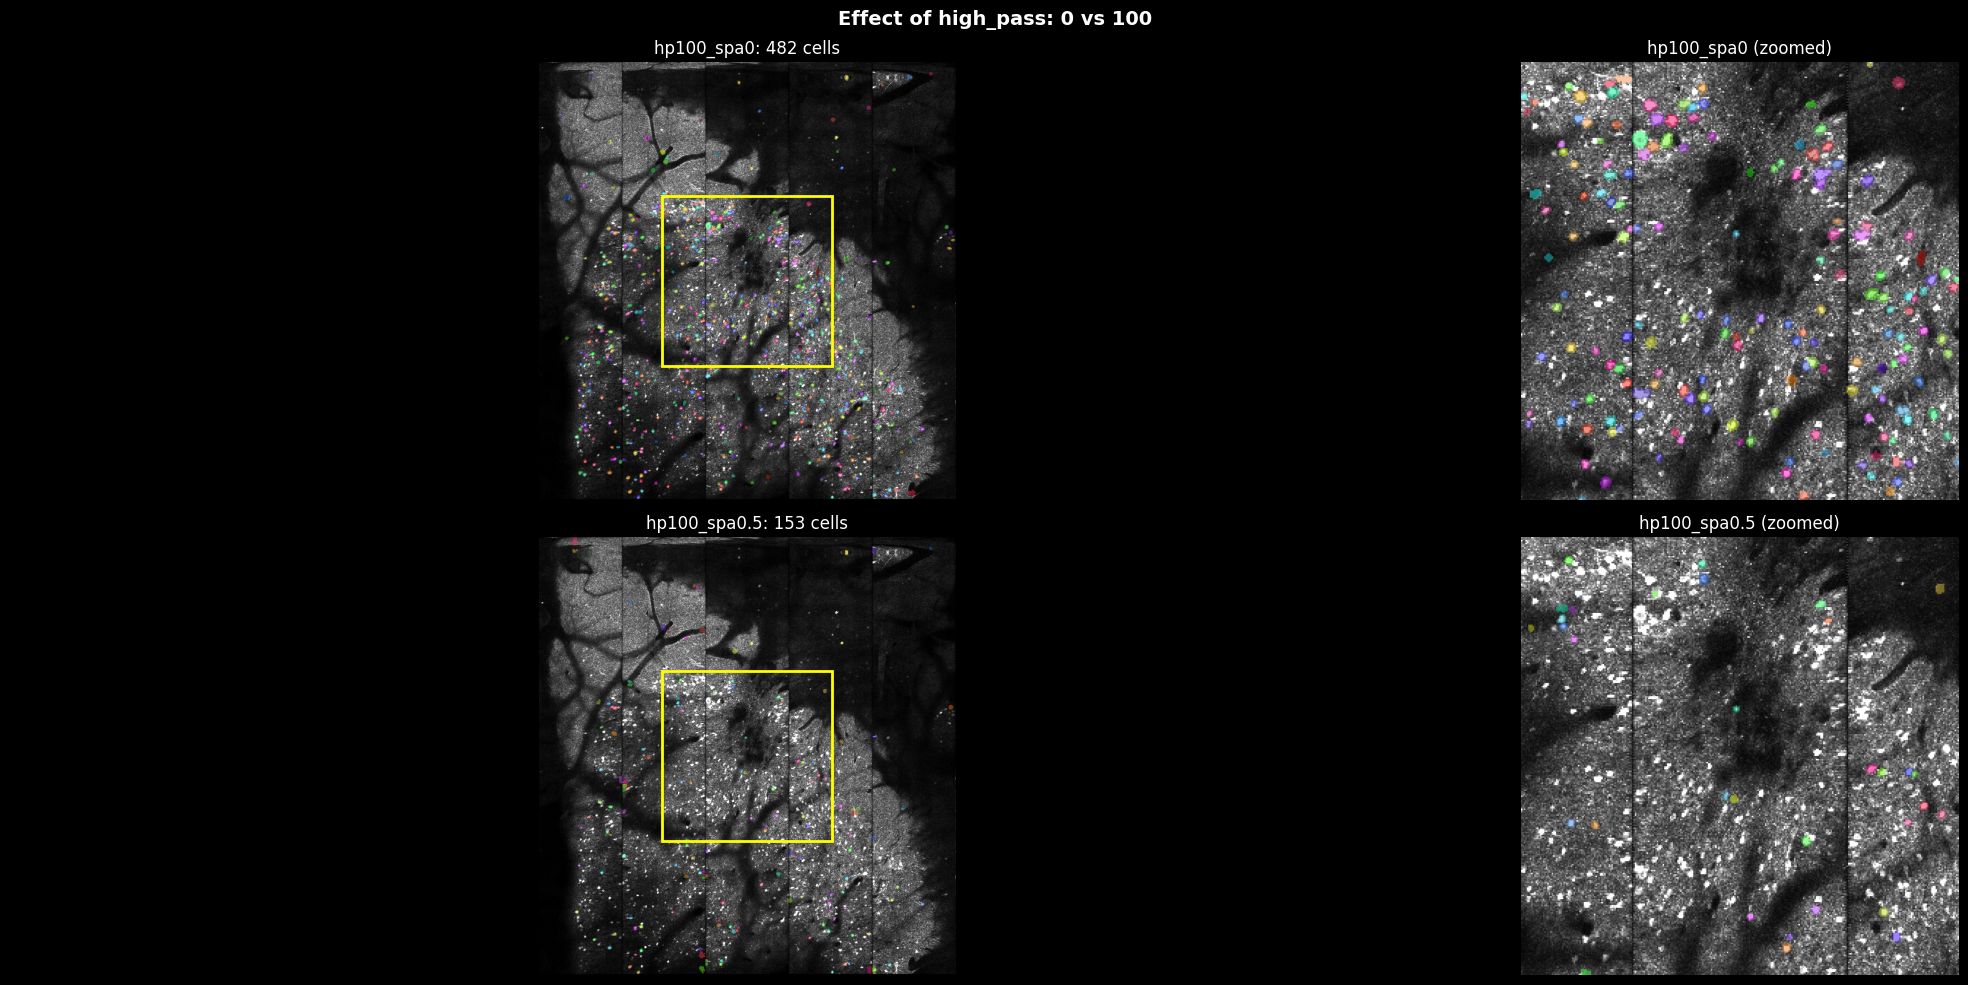

In [10]:
# Compare pairs: effect of high_pass (0 vs 100)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

pairs = [
    ('hp0_spa0', 'hp100_spa0', 'spatial_hp_cp=0'),
    ('hp0_spa0.5', 'hp100_spa0.5', 'spatial_hp_cp=0.5'),
]

for row_idx, (name1, name2, title) in enumerate(pairs):
    for col_idx, name in enumerate([name1, name2]):
        # Full image
        ax = axes[row_idx, col_idx]
        if name in results and 'stat' in results[name]:
            r = results[name]
            mask = stat_to_mask(r['stat'], Ly, Lx)
            overlay = mask_overlay(max_proj, mask)
            ax.imshow(overlay)
            ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                       fill=False, edgecolor='yellow', linewidth=2))
            ax.set_title(f"{name}: {r['n_cells']} cells")
        ax.axis('off')

        # Zoomed
        ax = axes[row_idx, col_idx + 2]
        if name in results and 'stat' in results[name]:
            ax.imshow(overlay[y1:y2, x1:x2])
            ax.set_title(f"{name} (zoomed)")
        ax.axis('off')

    axes[row_idx, 0].set_ylabel(title, fontsize=12, fontweight='bold')

plt.suptitle('Effect of high_pass: 0 vs 100', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparison_high_pass.png', dpi=150, bbox_inches='tight')
plt.show()

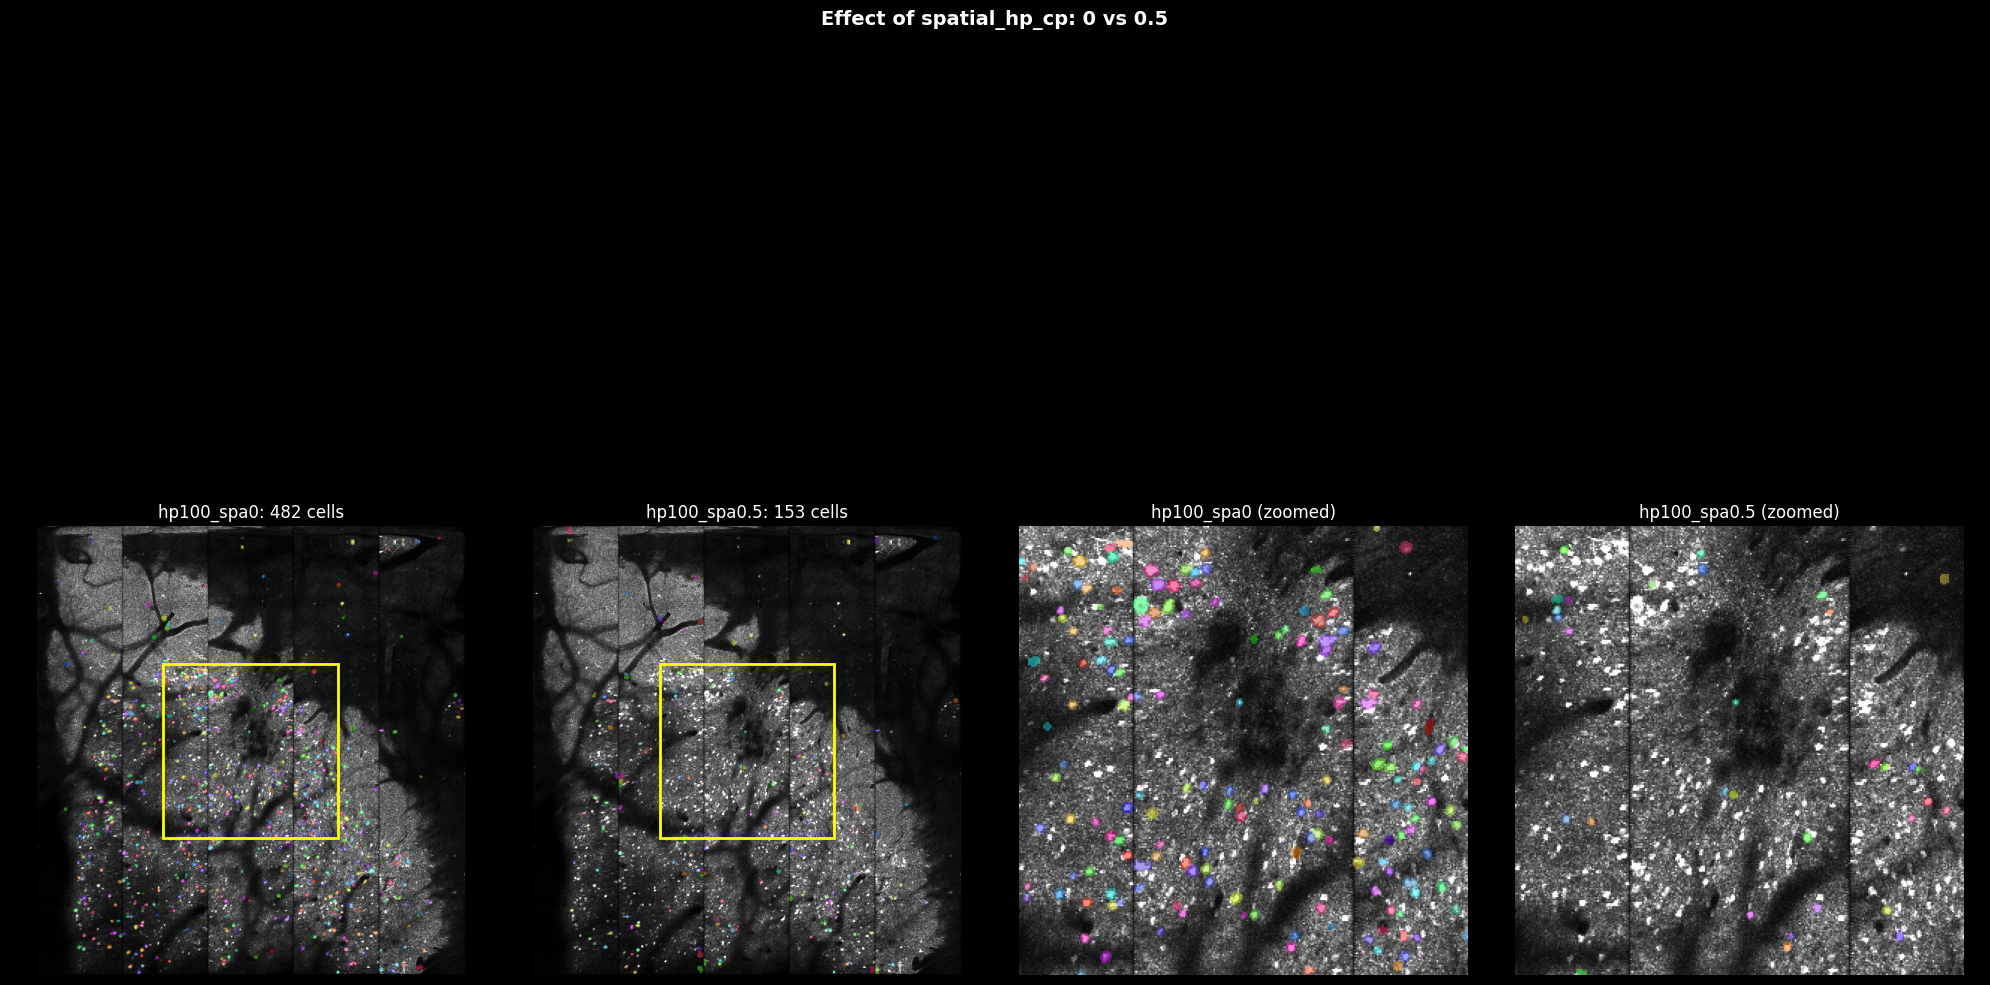

In [11]:
# Compare pairs: effect of spatial_hp_cp (0 vs 0.5)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

pairs = [
    ('hp0_spa0', 'hp0_spa0.5', 'high_pass=0'),
    ('hp100_spa0', 'hp100_spa0.5', 'high_pass=100'),
]

for row_idx, (name1, name2, title) in enumerate(pairs):
    for col_idx, name in enumerate([name1, name2]):
        # Full image
        ax = axes[row_idx, col_idx]
        if name in results and 'stat' in results[name]:
            r = results[name]
            mask = stat_to_mask(r['stat'], Ly, Lx)
            overlay = mask_overlay(max_proj, mask)
            ax.imshow(overlay)
            ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                       fill=False, edgecolor='yellow', linewidth=2))
            ax.set_title(f"{name}: {r['n_cells']} cells")
        ax.axis('off')

        # Zoomed
        ax = axes[row_idx, col_idx + 2]
        if name in results and 'stat' in results[name]:
            ax.imshow(overlay[y1:y2, x1:x2])
            ax.set_title(f"{name} (zoomed)")
        ax.axis('off')

    axes[row_idx, 0].set_ylabel(title, fontsize=12, fontweight='bold')

plt.suptitle('Effect of spatial_hp_cp: 0 vs 0.5', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparison_spatial_hp_cp.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell Size Distributions

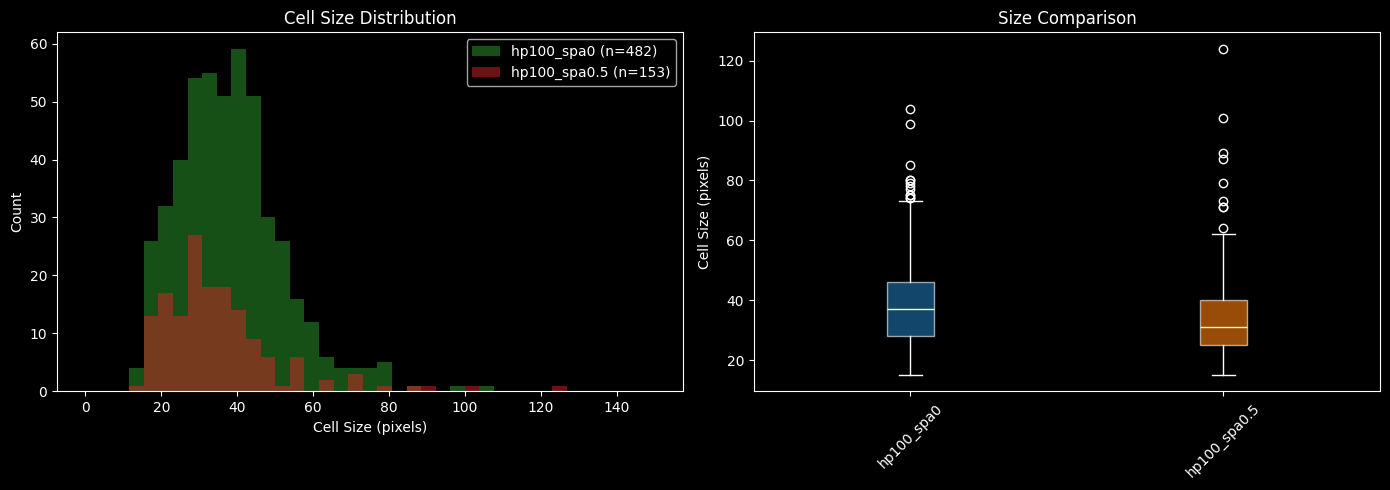

In [12]:
# Compute and compare cell sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.tab10.colors

# Histogram
ax = axes[0]
bins = np.linspace(0, 150, 40)
for i, (name, r) in enumerate(results.items()):
    if 'stat' in r:
        sizes = np.array([s['npix'] for s in r['stat']])
        ax.hist(sizes, bins=bins, alpha=0.5, label=f"{name} (n={len(sizes)})", color=colors[i])
ax.set_xlabel('Cell Size (pixels)')
ax.set_ylabel('Count')
ax.set_title('Cell Size Distribution')
ax.legend()

# Box plot
ax = axes[1]
data = []
labels = []
for name, r in results.items():
    if 'stat' in r:
        sizes = np.array([s['npix'] for s in r['stat']])
        data.append(sizes)
        labels.append(name)

if data:
    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(colors[i])
        patch.set_alpha(0.6)
ax.set_ylabel('Cell Size (pixels)')
ax.set_title('Size Comparison')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'size_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Table

In [13]:
print("\n" + "="*80)
print("GRID SEARCH V2 SUMMARY")
print("="*80)
print(f"\nFixed parameters:")
for k, v in FIXED_OPS.items():
    print(f"  {k}: {v}")

print(f"\n{'Name':<20} {'high_pass':>10} {'spatial_hp_cp':>15} {'Cells':>10} {'Med Size':>12} {'Time':>10}")
print("-"*80)

for name, r in results.items():
    hp = r['params']['high_pass']
    spa = r['params']['spatial_hp_cp']
    t = f"{r['time']:.1f}s" if 'time' in r else 'N/A'

    if 'stat' in r:
        sizes = np.array([s['npix'] for s in r['stat']])
        med_size = f"{np.median(sizes):.0f}px"
    else:
        med_size = 'N/A'

    print(f"{name:<20} {hp:>10} {spa:>15} {r['n_cells']:>10} {med_size:>12} {t:>10}")

print(f"\nResults saved to: {OUTPUT_DIR}")


GRID SEARCH V2 SUMMARY

Fixed parameters:
  do_registration: 0
  roidetect: 1
  anatomical_only: 4
  diameter: 2
  cellprob_threshold: -6.0
  flow_threshold: 0.0

Name                  high_pass   spatial_hp_cp      Cells     Med Size       Time
--------------------------------------------------------------------------------
hp0_spa0                      0               0          0          N/A       0.0s
hp0_spa0.5                    0             0.5          0          N/A       0.0s
hp100_spa0                  100               0        482         37px     133.9s
hp100_spa0.5                100             0.5        153         31px     126.6s

Results saved to: D:\cj\2025-11-21\results\grid_search_v2


## Load Results in Suite2p GUI

Each combination's results are saved in a separate folder that can be loaded directly in the Suite2p GUI.

In [14]:
print("Suite2p GUI compatible folders:")
print("="*60)
for name, r in results.items():
    if 'dir' in r:
        print(f"  {r['dir']}")

Suite2p GUI compatible folders:
  D:\cj\2025-11-21\results\grid_search_v2\hp100_spa0\plane01
  D:\cj\2025-11-21\results\grid_search_v2\hp100_spa0.5\plane01
